# TechMentor-LLM Dataset Report

Day 3 validation report: dataset overview, visualizations, quality checks, and sample records.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path("..").resolve()
CLEANED_PATH = ROOT / "data" / "cleaned" / "cleaned_dataset.json"
STATS_PATH = ROOT / "reports" / "dataset_stats.json"
TRAIN_PATH = ROOT / "data" / "processed" / "train.jsonl"
EVAL_PATH = ROOT / "data" / "processed" / "eval.jsonl"
CATEGORY_CHART = ROOT / "reports" / "category_distribution.png"
ANSWER_LENGTH_CHART = ROOT / "reports" / "answer_length_distribution.png"
SAMPLE_RECORDS = ROOT / "reports" / "sample_records.md"

## Dataset Overview

In [2]:
with STATS_PATH.open(encoding="utf-8") as handle:
    stats = json.load(handle)

with CLEANED_PATH.open(encoding="utf-8") as handle:
    cleaned = json.load(handle)

overview = pd.DataFrame(
    [
        {"Metric": "Dataset Version", "Value": stats["dataset_version"]},
        {"Metric": "Train Samples", "Value": stats["train_samples"]},
        {"Metric": "Eval Samples", "Value": stats["eval_samples"]},
        {"Metric": "Total Samples", "Value": stats["total_samples"]},
        {"Metric": "Cleaned Records", "Value": stats.get("cleaning", {}).get("total_records", len(cleaned))},
    ]
)
overview

,Metric,Value
0,Dataset Version,v1
1,Train Samples,504
2,Eval Samples,56
3,Total Samples,560
4,Cleaned Records,7928


In [3]:
source_df = pd.DataFrame(
    [{"Source": key, "Count": value} for key, value in stats["sources"].items()]
).sort_values("Count", ascending=False)
source_df

,Source,Count
2,codeqa,7692
0,hf_interview,186
1,kaggle,50


## Visualizations

In [4]:
category_df = pd.DataFrame(
    [{"Category": key.replace("_", " ").title(), "Count": value}
     for key, value in stats["categories"].items()]
)
category_df

,Category,Count
0,Backend,7
1,Python,7692
2,Sql,13
3,Ml,6
4,System Design,24


### Category Distribution

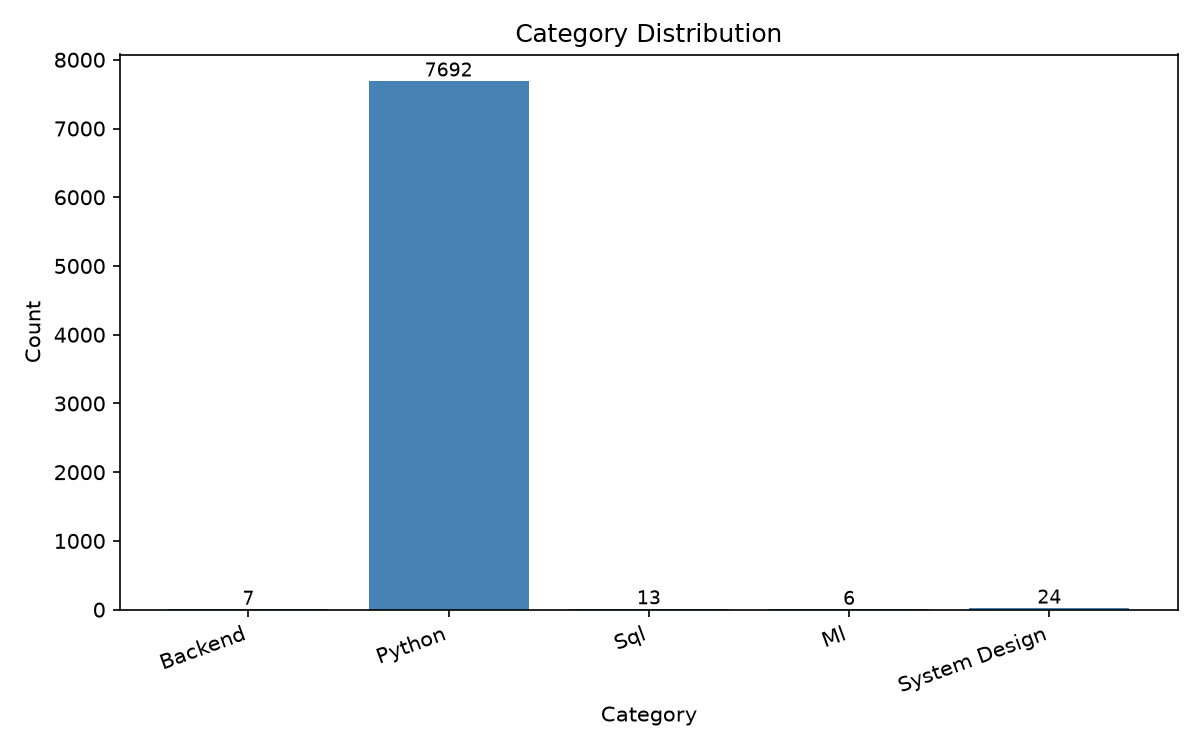

In [5]:
display(Markdown("### Category Distribution"))
display(Image(filename=str(CATEGORY_CHART)))

In [6]:
length_df = pd.DataFrame(
    [{"Metric": key.replace("_", " ").title(), "Words": value}
     for key, value in stats["answer_length"].items()]
)
length_df

,Metric,Words
0,Avg Answer Length,10.67
1,Median Answer Length,8.00
2,Max Answer Length,48.00
3,Min Answer Length,5.00


### Answer Length Distribution

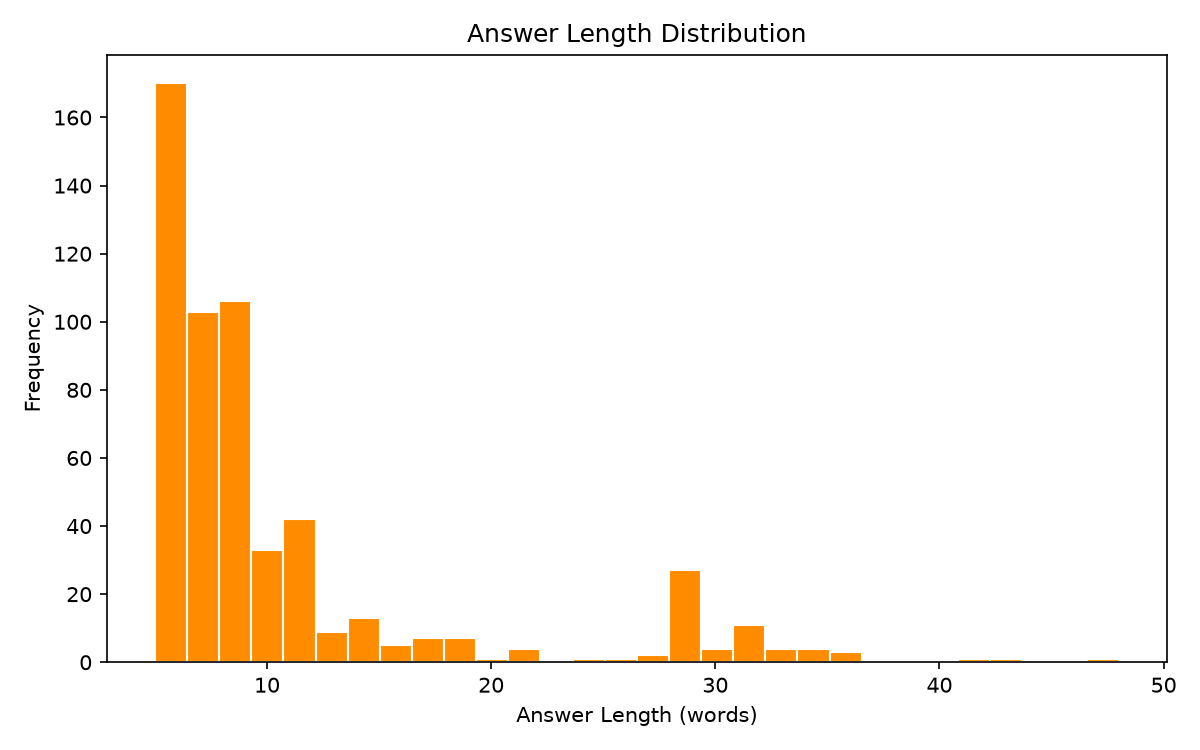

In [7]:
display(Markdown("### Answer Length Distribution"))
display(Image(filename=str(ANSWER_LENGTH_CHART)))

## Quality Checks

In [8]:
quality_rows = [
    {"Check": "Duplicate Inputs", "Count": stats["duplicates"]["duplicate_inputs"]},
    {"Check": "Duplicate Outputs", "Count": stats["duplicates"]["duplicate_outputs"]},
    {"Check": "Duplicates Removed (est.)", "Count": stats["duplicates"]["duplicates_removed"]},
    {"Check": "Cleaning Duplicates Removed", "Count": stats.get("cleaning", {}).get("duplicates_removed", 0)},
]
quality_df = pd.DataFrame(quality_rows)
quality_df

,Check,Count
0,Duplicate Inputs,0
1,Duplicate Outputs,54
2,Duplicates Removed (est.),54
3,Cleaning Duplicates Removed,16314


In [9]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open(encoding="utf-8") as handle:
        for line in handle:
            rows.append(json.loads(line))
    return rows

all_rows = load_jsonl(TRAIN_PATH) + load_jsonl(EVAL_PATH)
missing = sum(
    1
    for row in all_rows
    if not row.get("instruction") or not row.get("input") or not row.get("output")
)
pd.DataFrame([{"Check": "Missing Required Fields", "Count": missing}])

,Check,Count
0,Missing Required Fields,0


## Sample Records

In [10]:
rng = random.Random(42)
samples = rng.sample(all_rows, k=min(10, len(all_rows)))
pd.DataFrame(samples)

,instruction,input,output
0,Explain the following code.,Question: What does the code combine to amount...,many maps from group to counter
1,Answer the technical interview question.,What does the code salt ?,an md5 hash of time and username
2,Answer the technical interview question.,What list in an environment ?,all the available state modules
3,Explain the following code.,Question: For what purpose does the code add c...,to create - certificate - from - csr
4,Answer the technical interview question.,In which direction do messages delete messages ?,from region region where sqs queues
5,Explain the following code.,Question: What does a lambda function return ?...,a deep copy of the passed data
6,Explain the following code.,Question: How does resource open ?\nCode:\ndef...,either as a file with open()or as url with url...
7,Answer the technical interview question.,For what purpose do testsuites unpack ?,in order to generate a single stream of terminals
8,Answer the technical interview question.,Where does python code run ?,in the projects virtual environment
9,Answer the technical interview question.,How do stability of var(p ) system determine ?,by examining the eigenvalues of the var(1 ) re...


In [11]:
if SAMPLE_RECORDS.exists():
    display(Markdown(SAMPLE_RECORDS.read_text(encoding="utf-8")[:4000]))

# Sample Records

Random sample of 20 instruction-tuning examples for manual review.

## Sample 1

**Instruction:** Explain the following code.

**Input:**

```text
Question: What does the code combine to amount ?
Code:
def _sum_counters(*counters_list): result = {} for counters in counters_list: for (group, counter_to_amount) in counters.items(): for (counter, amount) in counter_to_amount.items(): result.setdefault(group, {}) result[group].setdefault(counter, 0) result[group][counter] += amount return result
```

**Output:**

```text
many maps from group to counter
```

## Sample 2

**Instruction:** Answer the technical interview question.

**Input:**

```text
What does the code salt ?
```

**Output:**

```text
an md5 hash of time and username
```

## Sample 3

**Instruction:** Answer the technical interview question.

**Input:**

```text
What list in an environment ?
```

**Output:**

```text
all the available state modules
```

## Sample 4

**Instruction:** Explain the following code.

**Input:**

```text
Question: For what purpose does the code add certificate - pem - outfile ?
Code:
def register_create_keys_from_csr_arguments(session, argument_table, **kwargs): argument_table['certificate-pem-outfile'] = QueryOutFileArgument(session=session, name='certificate-pem-outfile', query='certificatePem', after_call_event='after-call.iot.CreateCertificateFromCsr', perm=384)
```

**Output:**

```text
to create - certificate - from - csr
```

## Sample 5

**Instruction:** Answer the technical interview question.

**Input:**

```text
In which direction do messages delete messages ?
```

**Output:**

```text
from region region where sqs queues
```

## Sample 6

**Instruction:** Explain the following code.

**Input:**

```text
Question: What does a lambda function return ?
Code:
def data_to_lambda(data): return (lambda *args, **kwargs: copy.deepcopy(data))
```

**Output:**

```text
a deep copy of the passed data
```

## Sample 7

**Instruction:** Explain the following code.

**Input:**

```text
Question: How does resource open ?
Code:
def _json_from_url(url): parts = compat.urlparse(url) if (parts.scheme in ('', 'file')): handle = compat.open_unicode(parts.path) elif (len(parts.scheme) == 1): handle = compat.open_unicode(url) else: handle = compat.urlopen(url) try: desc = json.load(handle) except ValueError as e: import pdb pdb.set_trace() raise SyntaxError(('Syntax error in %s: %s' % (url, str(e)))) finally: handle.close() return desc
```

**Output:**

```text
either as a file with open()or as url with urlopen ( )
```

## Sample 8

**Instruction:** Answer the technical interview question.

**Input:**

```text
For what purpose do testsuites unpack ?
```

**Output:**

```text
in order to generate a single stream of terminals
```

## Sample 9

**Instruction:** Answer the technical interview question.

**Input:**

```text
Where does python code run ?
```

**Output:**

```text
in the projects virtual environment
```

## Sample 10

**Instruction:** Answer the technical interview question.

**Input:**

```text
How do stability of var(p ) system determine ?
```

**Output:**

```text
by examining the eigenvalues of the var(1 ) representation parameters coefs
```

## Sample 11

**Instruction:** Answer the technical interview question.

**Input:**

```text
What do an message box ask the user ?
```

**Output:**

```text
to select some predefined course of action
```

## Sample 12

**Instruction:** Answer the technical interview question.

**Input:**

```text
What does the code dehydrate to dict ?
```

**Output:**

```text
an object of content ratings from rating ids
```

## Sample 13

**Instruction:** Generate a follow-up interview question.

**Input:**

```text
Explain the concept of polymorphism.
```

**Output:**

```text
Could you elaborate on that?
```

## Sample 14

**Instruction:** Generate a follow-up interview question.

**Input:**

```text
I'd like to start by asking: What is a RESTful API?
```

**Output:**

```text
How would you apply t